In [167]:
import requests
import zipfile
from pathlib import Path

In [168]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"Found directory: {image_path}")
else:
    print(f"{image_path} is being created")
    image_path.mkdir(parents=True,exist_ok=True)
    
    
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza,steak and sushi")
    f.write(request.content)
    
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip",'r') as zip_ref:
    zip_ref.extractall(image_path)

Found directory: data/pizza_steak_sushi


In [169]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch 
from torch import nn
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader,Dataset
from torchvision.transforms import ToTensor
from tqdm.auto import tqdm
import random
import mlxtend
import os
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
from PIL import Image
from typing import Tuple,Dict,List
from pathlib import Path
from torchinfo import summary

In [171]:
def walk_through(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images")

In [172]:
walk_through(image_path)

There are 2 directories and 0 images
There are 3 directories and 0 images
There are 0 directories and 19 images
There are 0 directories and 31 images
There are 0 directories and 25 images
There are 3 directories and 0 images
There are 0 directories and 75 images
There are 0 directories and 72 images
There are 0 directories and 78 images


In [173]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [174]:
random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

[PosixPath('data/pizza_steak_sushi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/673127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/894825.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1868005.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/27415.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1016217.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1285886.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/502076.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/3424937.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/690177.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/354513.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2117351.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/100274.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2144308.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/966174.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1882831.jpg'),
 PosixPath('data/pizza_steak_sushi

Random Image Path : data/pizza_steak_sushi/test/pizza/2236338.jpg
Image Class : pizza
Image Size : (512, 512)
Image Width : 512


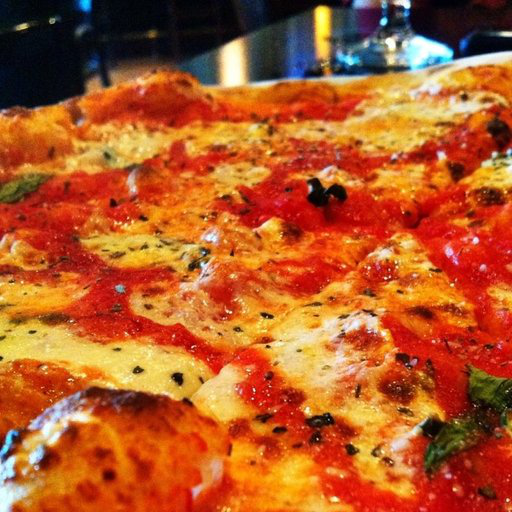

In [175]:
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"Random Image Path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Size : {img.size}")
print(f"Image Width : {img.width}")
img

(-0.5, 511.5, 511.5, -0.5)

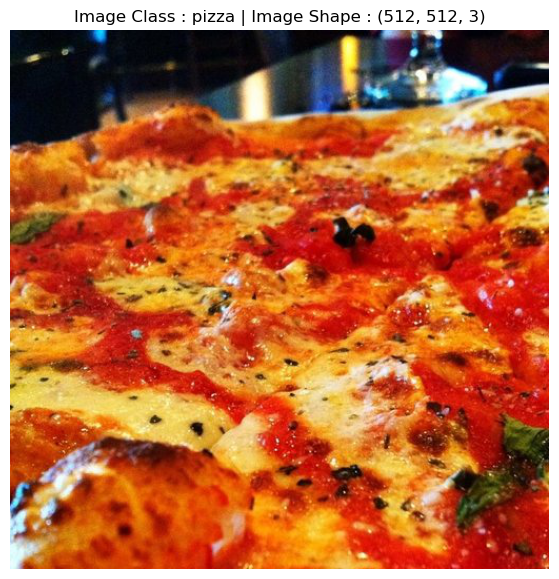

In [176]:
img_as_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image Class : {image_class} | Image Shape : {img_as_array.shape}")
plt.axis(False)

In [177]:
img_as_array

array([[[  7,  18,  38],
        [  5,  16,  34],
        [  2,  13,  31],
        ...,
        [ 18,   7,  11],
        [ 12,   6,   8],
        [  8,   4,   5]],

       [[  2,  13,  33],
        [  2,  13,  31],
        [  2,  13,  31],
        ...,
        [ 18,   9,  10],
        [ 17,  11,  13],
        [ 16,  12,  13]],

       [[  0,  11,  31],
        [  1,  12,  30],
        [  3,  14,  32],
        ...,
        [ 17,   8,   9],
        [ 16,  10,  12],
        [ 15,  11,  12]],

       ...,

       [[226, 249, 255],
        [229, 253, 255],
        [229, 255, 254],
        ...,
        [250, 149,  95],
        [240, 139,  83],
        [234, 130,  75]],

       [[220, 247, 254],
        [224, 252, 255],
        [226, 255, 253],
        ...,
        [236, 133,  88],
        [195,  88,  42],
        [170,  62,  16]],

       [[218, 247, 255],
        [223, 252, 255],
        [224, 254, 254],
        ...,
        [255, 157, 116],
        [208,  99,  60],
        [166,  52,  15]]

In [178]:
data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [179]:
data_transform(img).dtype

torch.float32

In [180]:
data_transform(img)

tensor([[[0.0157, 0.0157, 0.0118,  ..., 0.2314, 0.1922, 0.1020],
         [0.0157, 0.0157, 0.0157,  ..., 0.1137, 0.1059, 0.1216],
         [0.0157, 0.0235, 0.0902,  ..., 0.1098, 0.1255, 0.1608],
         ...,
         [0.8510, 0.8235, 0.8000,  ..., 0.4314, 0.6353, 0.6941],
         [0.8667, 0.8392, 0.7922,  ..., 0.4824, 0.6235, 0.7412],
         [0.8627, 0.7373, 0.7255,  ..., 0.6627, 0.6549, 0.8000]],

        [[0.0588, 0.0510, 0.0392,  ..., 0.0510, 0.0471, 0.0392],
         [0.0549, 0.0471, 0.0431,  ..., 0.0431, 0.0431, 0.0549],
         [0.0667, 0.0706, 0.1176,  ..., 0.0510, 0.0431, 0.0510],
         ...,
         [0.9529, 0.8824, 0.8157,  ..., 0.1098, 0.0627, 0.0627],
         [0.9804, 0.8510, 0.6353,  ..., 0.0667, 0.0824, 0.2392],
         [0.9412, 0.5451, 0.3176,  ..., 0.0745, 0.0980, 0.3098]],

        [[0.1176, 0.0745, 0.0667,  ..., 0.0588, 0.0510, 0.0392],
         [0.1137, 0.0863, 0.0784,  ..., 0.0431, 0.0392, 0.0510],
         [0.0941, 0.0941, 0.1255,  ..., 0.0588, 0.0510, 0.

In [181]:
data_transform(img).shape

torch.Size([3, 64, 64])

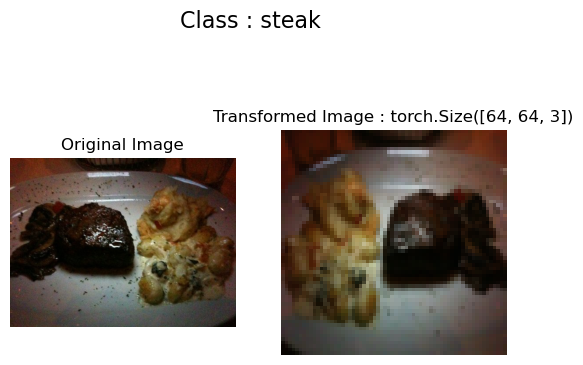

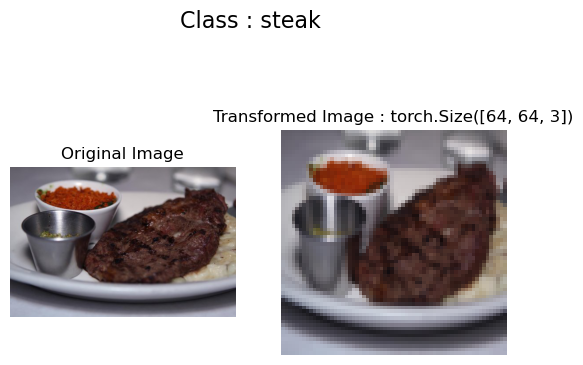

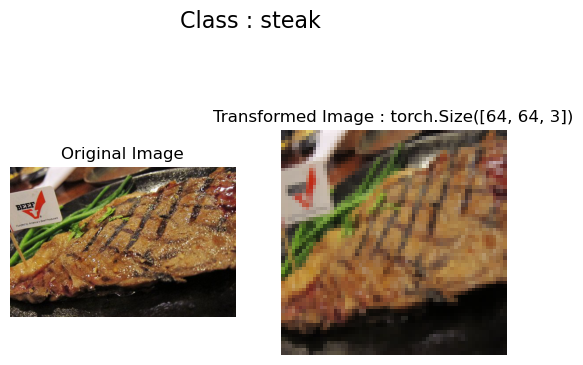

In [182]:
def plot_transformed_image(image_paths:list,transform,n=3,seed=None):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title('Original Image')
            ax[0].axis('off')
            
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed Image : {transformed_image.shape}")
            ax[1].axis(False)
            
            plt.suptitle(f"Class : {image_path.parent.stem}",fontsize=16)
            
plot_transformed_image(image_paths = image_path_list,
                        transform = data_transform,
                        n=3)

In [183]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform = data_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,transform=data_transform)

In [184]:
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [185]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [186]:
classnames = train_data.classes
classnames

['pizza', 'steak', 'sushi']

In [187]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [188]:
img,label = train_data[0][0],train_data[0][1]
img.shape,img.dtype

(torch.Size([3, 64, 64]), torch.float32)

Text(0.5, 1.0, 'pizza')

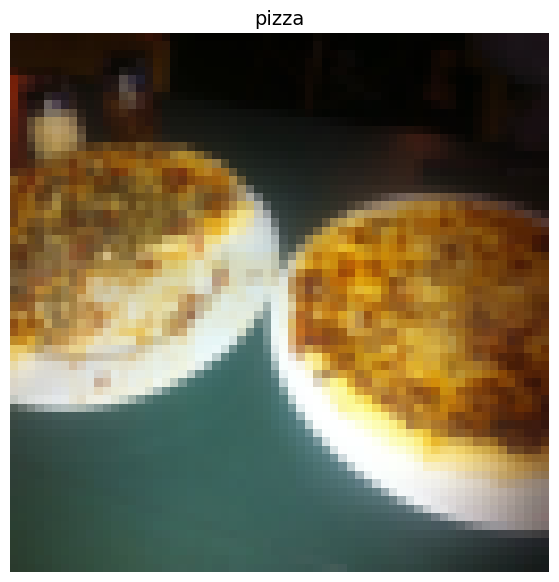

In [189]:
img_permute = img.permute(1,2,0)
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(classnames[label],fontsize=14)

In [190]:
img_permute.shape

torch.Size([64, 64, 3])

In [191]:
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=1,shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False)

In [192]:
len(train_dataloader),len(test_dataloader)

(225, 75)

In [193]:
img,label = next(iter(train_dataloader))
img.shape,label.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

In [194]:
target_directory = train_dir
print(f"Target Dir:{target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
print(f"Class Names Found: {class_names_found}")

Target Dir:data/pizza_steak_sushi/train
Class Names Found: ['pizza', 'steak', 'sushi']


In [195]:
def class_helper(directory:str) -> Tuple[list[str], Dict[str,int]]:  
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    
    if not classes:
        raise FileNotFoundError(f"No classes in {target_directory}")
    
    class_to_idx = {class_name:i for i,class_name in enumerate(classes)}
    return classes,class_to_idx

In [196]:
class_helper(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [197]:
import pathlib


class ImageFolderCustom(Dataset):
    def __init__(self,target_dir:str,transform=None):
        self.paths = list(pathlib.Path(target_dir).glob('*/*.jpg'))
        self.transform = transform
        self.classes,self.class_to_idx = class_helper(target_dir)
        
    def load_image(self,index:int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)
    
    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index:int) -> Tuple[torch.Tensor,int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]
        
        if self.transform:
            return self.transform(img),class_idx
        else:
            return img, class_idx

In [198]:
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [199]:
train_data_custom = ImageFolderCustom(target_dir=train_dir,transform=train_transforms)
test_data_custom = ImageFolderCustom(target_dir=test_dir,transform=test_transforms)

In [200]:
len(train_data_custom),len(test_data_custom)

(225, 75)

In [201]:
print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data.classes)

True
True


In [202]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes : List[str] = None,
                          n : int = 10,
                          display_shape: bool = True,
                          seed : int = None):
    if n > 10:
        n = 10
        display_shape = False
    
    if seed:
        random.seed(seed)
    
    random_samples_idx = random.sample(range(len(dataset)),k=n)
    
    plt.figure(figsize=(16,8))
    
    for i,target_sample in enumerate(random_samples_idx):
        target_image,target_label = dataset[target_sample][0],dataset[target_sample][1]
        
        target_image_adjust = target_image.permute(1,2,0)
        
        plt.subplot(1,n,i+1)
        plt.imshow(target_image_adjust)
        plt.axis(False)
        plt.title(f"Label: {classes[target_label]}")

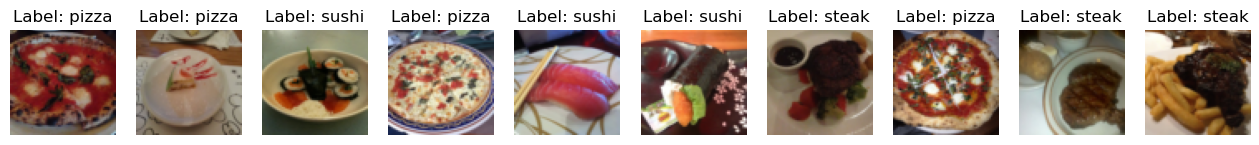

In [203]:
display_random_images(dataset=train_data,n=10,classes=classnames,seed=None)

In [204]:
BATCH_SIZE = 32
NUM_WORKERS = 0
train_dataloader_custom = DataLoader(
    dataset = train_data_custom,
    num_workers=NUM_WORKERS,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader_custom = DataLoader(
    dataset = test_data_custom,
    num_workers=NUM_WORKERS,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [205]:
len(train_dataloader_custom),len(test_dataloader_custom)

(8, 3)

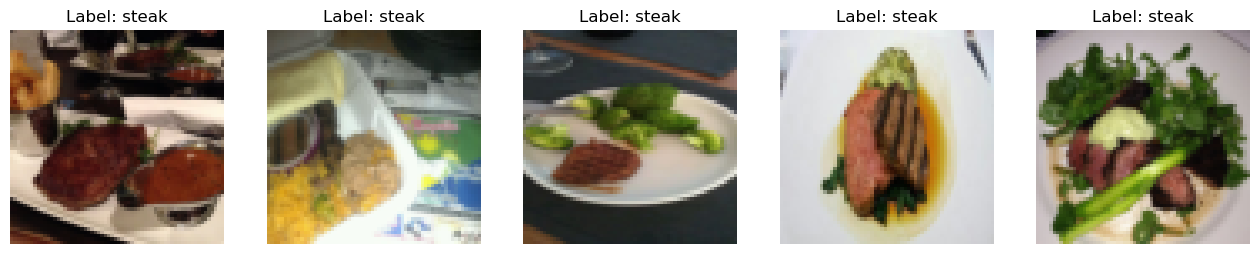

In [206]:
display_random_images(dataset=train_data_custom,n=5,classes=classnames,seed=None)

In [207]:
image_custom,label_custom = next(iter(train_dataloader_custom))
image_custom.shape,label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [208]:
train_transforms1 = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=10),
    transforms.ToTensor(),
])

test_transforms1 = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [209]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/673127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/894825.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1868005.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/27415.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1016217.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1285886.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/502076.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/3424937.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/690177.jpg')]

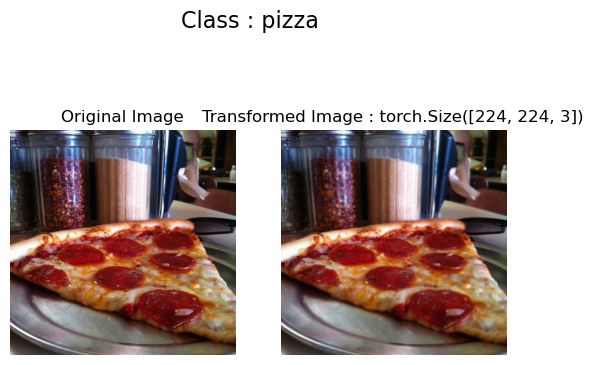

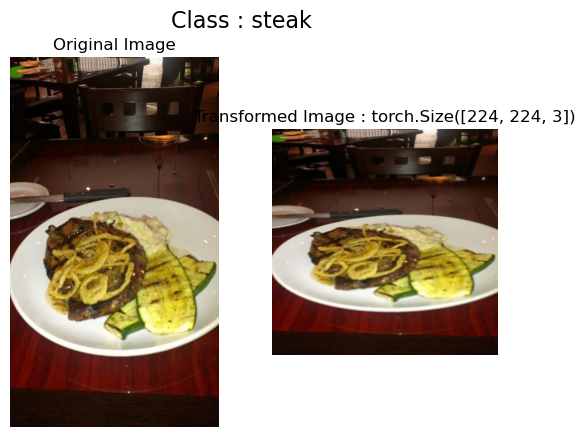

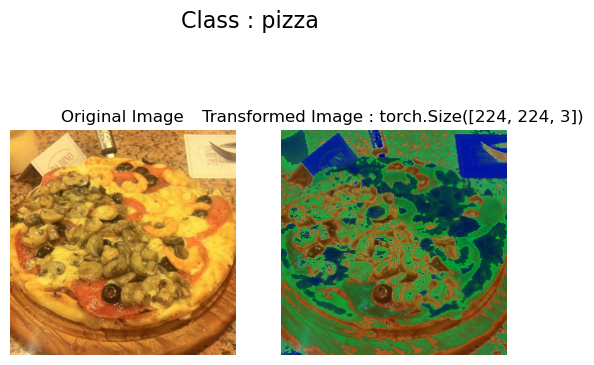

In [210]:
plot_transformed_image(image_paths=image_path_list,
                       transform = train_transforms1,
                       n=3,seed=None)

In [211]:
simple_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [212]:
train_data_simple = datasets.ImageFolder(root=train_dir,transform=simple_transforms)
test_data_simple = datasets.ImageFolder(root=test_dir,transform=simple_transforms)

In [213]:
len(train_data_simple),len(test_data_simple)

(225, 75)

In [214]:
BATCH_SIZE = 32
NUM_WORKERS = 1
train_dataloader_simple = DataLoader(
    dataset=train_data_simple,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)
test_dataloader_simple = DataLoader(
    dataset=test_data_simple,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
    
)

In [215]:
train_dataloader_simple,test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x3433c7d90>,
 <torch.utils.data.dataloader.DataLoader at 0x338cdcfd0>)

In [216]:
class NonLinearFn(nn.Module):
    def __init__(self,input_features:int,hidden_units:int,output_features:int):
        super().__init__()
        self.layer_stack1 = nn.Sequential(
            nn.Conv2d(in_channels=input_features,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.layer_stack2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16
                      ,out_features=output_features)
        )
        
    def forward(self,x):
        x = self.layer_stack1(x)
        # print(x.shape)
        x = self.layer_stack2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
    


In [217]:
torch.manual_seed(42)
model_0 = NonLinearFn(input_features=3,hidden_units=16,output_features=len(classnames))

In [218]:
model_0

NonLinearFn(
  (layer_stack1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_stack2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=3, bias=True)
  )
)

In [219]:
model_0.state_dict()

OrderedDict([('layer_stack1.0.weight',
              tensor([[[[ 0.1471,  0.1597, -0.0451],
                        [ 0.1768, -0.0422,  0.0388],
                        [-0.0937,  0.1130,  0.1697]],
              
                       [[-0.1412,  0.1673,  0.0360],
                        [ 0.1422,  0.0261,  0.0928],
                        [-0.0272,  0.1484,  0.0284]],
              
                       [[-0.0898,  0.0491, -0.0887],
                        [-0.0226, -0.0782,  0.1277],
                        [-0.1519, -0.0887, -0.0543]]],
              
              
                      [[[-0.1157,  0.0182, -0.1901],
                        [ 0.1738, -0.1635,  0.1486],
                        [ 0.0320, -0.0625,  0.1189]],
              
                       [[ 0.0300,  0.1555,  0.0210],
                        [-0.0607,  0.0517, -0.0522],
                        [ 0.0810,  0.1718,  0.1112]],
              
                       [[-0.0841,  0.1111,  0.0344],
                 

In [220]:
image_batch,label_batch = next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [221]:
model_0(image_batch)

tensor([[-1.7107e-02,  3.6350e-04,  4.6833e-03],
        [-1.8478e-02, -3.3707e-03, -2.3741e-03],
        [-1.6417e-02, -3.7610e-03, -9.3813e-05],
        [-1.6194e-02, -2.8283e-03,  4.9639e-04],
        [-1.5718e-02,  1.5077e-03, -6.3151e-04],
        [-1.2342e-02, -4.2666e-03,  4.2960e-03],
        [-1.4937e-02, -6.2023e-03, -3.3859e-03],
        [-1.5747e-02,  2.8251e-03,  1.4379e-04],
        [-1.4967e-02, -3.4014e-03,  2.0118e-03],
        [-1.8507e-02, -3.2458e-03,  2.8467e-04],
        [-1.7181e-02, -5.2212e-03,  6.4780e-03],
        [-1.8523e-02, -4.3834e-03,  8.8380e-04],
        [-2.2422e-02, -1.7976e-04, -1.9290e-03],
        [-1.8749e-02, -9.1369e-04, -1.6961e-03],
        [-2.0278e-02, -3.3830e-03, -8.9434e-04],
        [-2.0792e-02, -3.7018e-04,  5.0047e-03],
        [-1.6254e-02, -5.3219e-03, -1.2875e-03],
        [-2.1939e-02, -9.1903e-04,  1.3593e-03],
        [-1.3173e-02, -2.4880e-03,  3.4846e-03],
        [-1.6344e-02, -2.6981e-03,  1.6251e-03],
        [-1.6393e-02

In [222]:
16*16*16


4096

In [223]:
model = model_0
batch_size = BATCH_SIZE
summary(model,input_size=(batch_size,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
NonLinearFn                              [32, 3]                   --
├─Sequential: 1-1                        [32, 16, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 16, 64, 64]          448
│    └─ReLU: 2-2                         [32, 16, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 16, 64, 64]          2,320
│    └─ReLU: 2-4                         [32, 16, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 16, 32, 32]          --
├─Sequential: 1-2                        [32, 16, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 16, 32, 32]          2,320
│    └─ReLU: 2-7                         [32, 16, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 16, 32, 32]          2,320
│    └─ReLU: 2-9                         [32, 16, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 16, 16, 16]          --
├─Seq

In [242]:
def train_step(model:torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               optimizer : torch.optim.Optimizer,
               loss_fn:torch.nn.Module,
):
    model.train()
    
    train_loss,train_acc = 0,0
    for batch,(X,y) in enumerate(dataloader):
        # X,y = X.to(device),y.to(device)
        y_pred = model(X)
        
        loss = loss_fn(y_pred, y)

        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
        train_acc += (y_pred_class==y).sum().item()/len(y_pred)
        
        
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss,train_acc
    


    
   
        
    
    

In [243]:
def test_step(model : torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module):
    
    model.eval()
    test_loss,test_acc = 0,0
    with torch.inference_mode():
        for batch,(X,y) in enumerate(dataloader):
            
            test_pred = model_0(X)
            loss = loss_fn(test_pred,y)
            test_loss += loss.item()
            test_pred_labels = test_pred.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)
            
        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)
        return test_loss,test_acc

In [244]:
loss_fn1 = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr = 0.1)

In [249]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs:int):
        results = {"train_loss":[],"train_acc":[],"test_loss":[],"test_acc":[]}

        for epoch in tqdm(range(epochs)):
                train_loss,train_acc = train_step(
                        model=model,
                        dataloader=train_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn)
                test_loss,test_acc = test_step(
                        model=model,
                        dataloader=test_dataloader,
                        loss_fn=loss_fn)
                
                print(
                f"Epoch: {epoch+1} | "
                f"train_loss: {train_loss:.4f} | "
                f"train_acc: {train_acc:.4f} | "
                f"test_loss: {test_loss:.4f} | "
                f"test_acc: {test_acc:.4f}"
                )
            
                print("-------------------------------------------------")
                results["train_loss"].append(train_loss)
                results["train_acc"].append(train_acc)
                results["test_loss"].append(test_loss)
                results["test_acc"].append(test_acc)
        return results
        


In [259]:
torch.manual_seed(42)
model_0_results = train(model=model_0,train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer= optimizer,
                        loss_fn=loss_fn1,
                        epochs=15)


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1296 | train_acc: 0.4727 | test_loss: 1.2452 | test_acc: 0.2604
-------------------------------------------------
Epoch: 2 | train_loss: 1.0795 | train_acc: 0.4219 | test_loss: 1.4713 | test_acc: 0.2604
-------------------------------------------------
Epoch: 3 | train_loss: 1.0985 | train_acc: 0.4023 | test_loss: 1.1802 | test_acc: 0.2604
-------------------------------------------------
Epoch: 4 | train_loss: 1.1273 | train_acc: 0.3047 | test_loss: 1.1680 | test_acc: 0.2604
-------------------------------------------------
Epoch: 5 | train_loss: 1.0855 | train_acc: 0.4258 | test_loss: 1.1660 | test_acc: 0.2604
-------------------------------------------------
Epoch: 6 | train_loss: 1.1113 | train_acc: 0.3047 | test_loss: 1.1639 | test_acc: 0.2604
-------------------------------------------------
Epoch: 7 | train_loss: 1.1000 | train_acc: 0.3047 | test_loss: 1.1662 | test_acc: 0.2292
-------------------------------------------------
Epoch: 8 | train_loss: 1.09

In [260]:
model_0_results

{'train_loss': [1.129561610519886,
  1.079507127404213,
  1.098529413342476,
  1.127348005771637,
  1.085492692887783,
  1.1112794131040573,
  1.099955603480339,
  1.0935744047164917,
  1.122658833861351,
  1.0909941345453262,
  1.087649442255497,
  1.1156587600708008,
  1.089197039604187,
  1.0866391584277153,
  1.0853055119514465],
 'train_acc': [0.47265625,
  0.421875,
  0.40234375,
  0.3046875,
  0.42578125,
  0.3046875,
  0.3046875,
  0.4140625,
  0.3046875,
  0.42578125,
  0.42578125,
  0.3046875,
  0.42578125,
  0.42578125,
  0.42578125],
 'test_loss': [1.2451973954836528,
  1.4713195363680522,
  1.1801594893137615,
  1.1679930090904236,
  1.1659902731577556,
  1.1638727982838948,
  1.1661838293075562,
  1.1624213059743245,
  1.1242554187774658,
  1.1310206254323323,
  1.1365442673365276,
  1.1066227356592815,
  1.1190274556477864,
  1.127730369567871,
  1.1347271998723347],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2

In [252]:
model_0_results.keys()
model_0_results.items()

dict_items([('train_loss', [1.0811348110437393, 1.0584955960512161, 1.125338651239872, 1.1037103086709976, 1.0598000884056091]), ('train_acc', [0.42578125, 0.4375, 0.3984375, 0.3046875, 0.4921875]), ('test_loss', [1.1605608661969502, 1.9389823873837788, 1.1542685429255168, 1.2294480005900066, 1.151720941066742]), ('test_acc', [0.2604166666666667, 0.2604166666666667, 0.2604166666666667, 0.19791666666666666, 0.2604166666666667])])

In [257]:
def plot_loss_curves(results:dict[str,list[float]]):
    
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    
    train_acc = results["train_acc"]
    test_acc = results["test_acc"]
    
    epochs = range(len(results["train_loss"]))
    plt.figure(figsize=(10,7))
    
    plt.subplot(1,2,1)
    plt.plot(epochs,train_loss,label="Train Loss")
    plt.plot(epochs,test_loss,label="Test Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(epochs,train_acc,label="Train_Accuracy")
    plt.plot(epochs,test_acc,label="Test_Accuracy")
    plt.title("Accuracy Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.show()

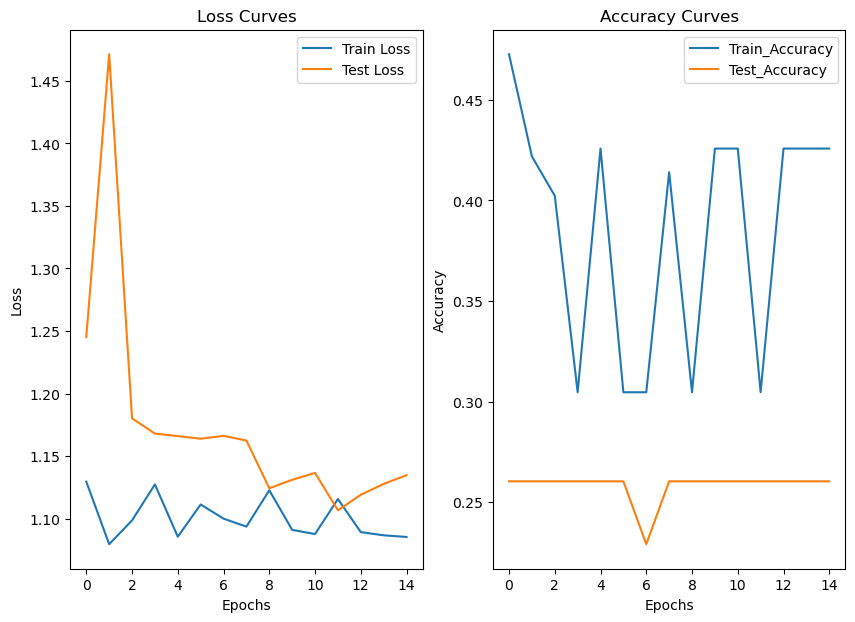

In [261]:
plot_loss_curves(model_0_results)

In [262]:
train_transforms_augmented = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=10),
    transforms.ToTensor(),
])

test_transforms_augmented = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor(),  
])

    

In [263]:
train_data_augmented = datasets.ImageFolder(root=train_dir,transform=train_transforms_augmented)
test_data_augmented = datasets.ImageFolder(root=test_dir,transform=test_transforms_augmented)

In [264]:
len(train_data_augmented),len(test_data_augmented)


(225, 75)

In [265]:
BATCH_SIZE = 32
NUM_WORKERS = 1
train_dataloader_augmented = DataLoader(
      dataset=train_data_augmented,
      batch_size=BATCH_SIZE,
      num_workers=NUM_WORKERS,
      shuffle=True,
)

test_dataloader_augmented = DataLoader(
    dataset=test_data_augmented,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

In [266]:
train_dataloader_augmented,test_dataloader_augmented

(<torch.utils.data.dataloader.DataLoader at 0x33f1301d0>,
 <torch.utils.data.dataloader.DataLoader at 0x33f01a4d0>)

In [267]:
class TinyVGGAUG(nn.Module):
    def __init__(self,input_features:int,hidden_units:int,output_features:int):
        super().__init__()
        self.layer_s1 = nn.Sequential(
            nn.Conv2d(in_channels=input_features,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.layer_s2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.layer_s3 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16,out_features=hidden_units)
        )
        
    def forward(self,x):
        x = self.layer_s1(x)
        x = self.layer_s2(x)
        x = self.layer_s3(x)
        return x

In [274]:
model_1 = TinyVGGAUG(input_features=3,hidden_units=16,output_features=len(train_data_augmented.classes))

In [275]:
model_1

TinyVGGAUG(
  (layer_s1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_s2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_s3): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=16, bias=True)
  )
)

In [276]:
loss_fn2 = torch.nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

In [277]:
torch.manual_seed(42)
model_1_results = train(model=model_1,
      train_dataloader=train_dataloader_augmented,
      test_dataloader=test_dataloader_augmented,
      optimizer=optimizer2,
      loss_fn=loss_fn2,
      epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.9811 | train_acc: 0.3828 | test_loss: 1.1347 | test_acc: 0.2604
-------------------------------------------------
Epoch: 2 | train_loss: 1.1653 | train_acc: 0.2656 | test_loss: 1.1347 | test_acc: 0.2604
-------------------------------------------------
Epoch: 3 | train_loss: 1.1819 | train_acc: 0.2969 | test_loss: 1.1347 | test_acc: 0.2604
-------------------------------------------------
Epoch: 4 | train_loss: 1.1080 | train_acc: 0.2891 | test_loss: 1.1347 | test_acc: 0.2604
-------------------------------------------------
Epoch: 5 | train_loss: 1.1334 | train_acc: 0.3047 | test_loss: 1.1347 | test_acc: 0.2604
-------------------------------------------------
Epoch: 6 | train_loss: 1.1438 | train_acc: 0.3203 | test_loss: 1.1347 | test_acc: 0.2604
-------------------------------------------------
Epoch: 7 | train_loss: 1.0910 | train_acc: 0.4336 | test_loss: 1.1347 | test_acc: 0.2604
-------------------------------------------------
Epoch: 8 | train_loss: 1.15

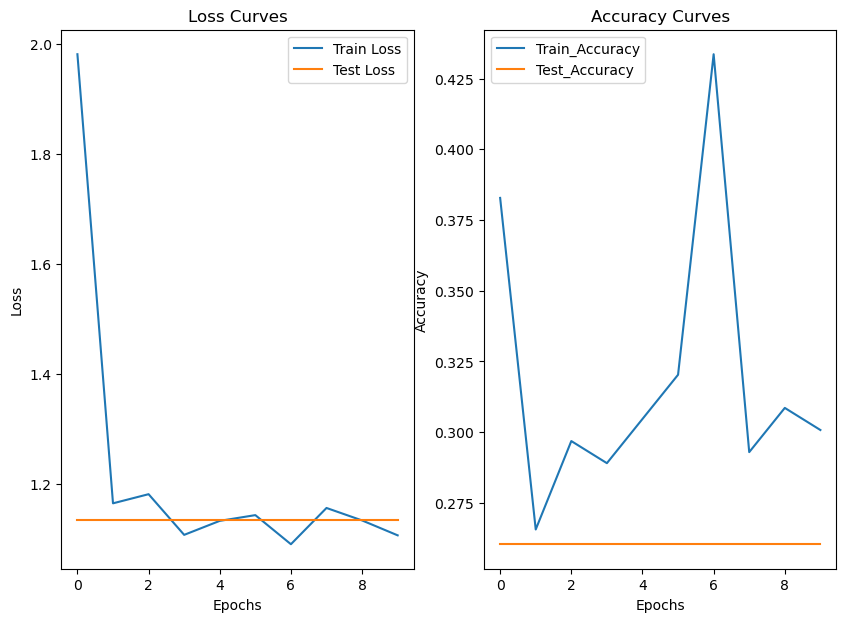

In [278]:
plot_loss_curves(model_1_results)

In [280]:
model_1_df = pd.DataFrame(model_1_results)
model_0_df = pd.DataFrame(model_0_results)
model_1_df

,train_loss,train_acc,test_loss,test_acc
0,1.981110,0.382812,1.134727,0.260417
1,1.165254,0.265625,1.134727,0.260417
2,1.181851,0.296875,1.134727,0.260417
3,1.107958,0.289062,1.134727,0.260417
4,1.133390,0.304688,1.134727,0.260417
5,1.143823,0.320312,1.134727,0.260417
6,1.090957,0.433594,1.134727,0.260417
7,1.156816,0.292969,1.134727,0.260417
8,1.134172,0.308594,1.134727,0.260417
9,1.107084,0.300781,1.134727,0.260417


In [281]:
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.129562,0.472656,1.245197,0.260417
1,1.079507,0.421875,1.471320,0.260417
2,1.098529,0.402344,1.180159,0.260417
3,1.127348,0.304688,1.167993,0.260417
4,1.085493,0.425781,1.165990,0.260417
5,1.111279,0.304688,1.163873,0.260417
6,1.099956,0.304688,1.166184,0.229167
7,1.093574,0.414062,1.162421,0.260417
8,1.122659,0.304688,1.124255,0.260417
9,1.090994,0.425781,1.131021,0.260417


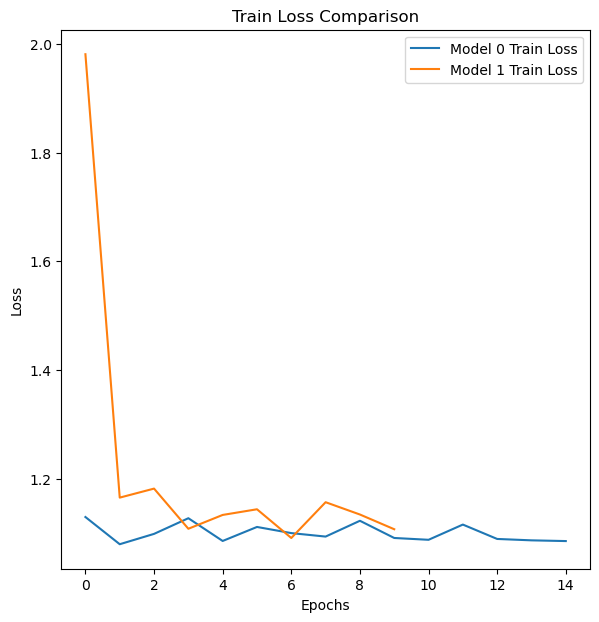

In [284]:
plt.figure(figsize=(15,7))
epochs = range(len(model_0_df["train_loss"]))
plt.subplot(1,2,1)
plt.plot(model_0_df["train_loss"],label="Model 0 Train Loss")
plt.plot(model_1_df["train_loss"],label="Model 1 Train Loss")
plt.title("Train Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
